In [57]:
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay , confusion_matrix , accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [58]:
df = pd.read_csv('synthetic_adult_like_dataset.csv')
df.head(10)

,age,education,marital-status,hours-per-week,workclass,income
0,56,Bachelors,Divorced,53,Private,>50K
1,69,HS-grad,Married,39,Private,<=50K
2,46,Doctorate,Married,38,Self-emp,<=50K
3,32,HS-grad,Divorced,53,Self-emp,>50K
4,60,Doctorate,Divorced,28,Private,<=50K
5,25,Bachelors,Married,38,Government,<=50K
6,38,HS-grad,Married,57,Government,>50K
7,56,Bachelors,Single,44,Private,>50K
8,36,Bachelors,Single,47,Government,>50K
9,40,Some-college,Single,52,Self-emp,>50K


In [59]:
df.columns

Index(['age', 'education', 'marital-status', 'hours-per-week', 'workclass',
       'income'],
      dtype='object')

In [60]:
df.info

<bound method DataFrame.info of        age  education marital-status  hours-per-week   workclass income
0       56  Bachelors       Divorced              53     Private   >50K
1       69    HS-grad        Married              39     Private  <=50K
2       46  Doctorate        Married              38    Self-emp  <=50K
3       32    HS-grad       Divorced              53    Self-emp   >50K
4       60  Doctorate       Divorced              28     Private  <=50K
...    ...        ...            ...             ...         ...    ...
49995   66  Doctorate         Single              26     Private  <=50K
49996   35  Bachelors       Divorced              37     Private  <=50K
49997   28    Masters       Divorced              43     Private  <=50K
49998   59  Doctorate        Married              47     Private   >50K
49999   35  Bachelors       Divorced              53  Government   >50K

[50000 rows x 6 columns]>

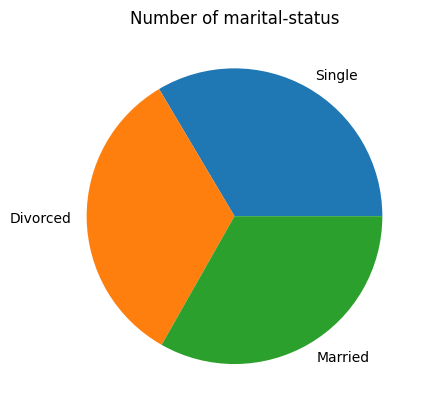

In [61]:
number_marital = df['marital-status'].value_counts().to_dict()
plt.pie(number_marital.values(),labels=number_marital.keys())
plt.title('Number of marital-status')
plt.show()

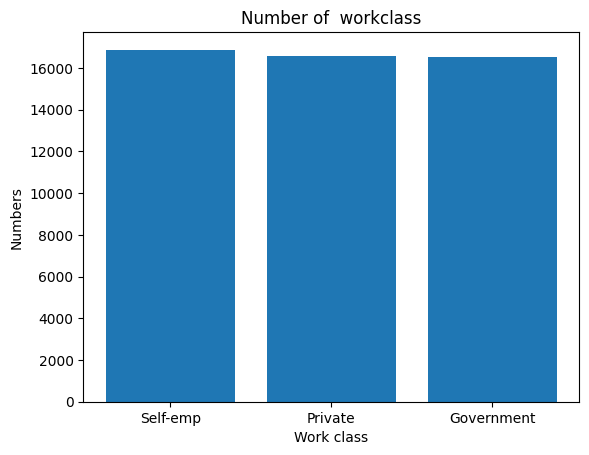

In [62]:
number_workclass = df['workclass'].value_counts().to_dict()
plt.bar(number_workclass.keys(),number_workclass.values())
plt.xlabel('Work class')
plt.ylabel('Numbers')
plt.title('Number of  workclass')
plt.show()

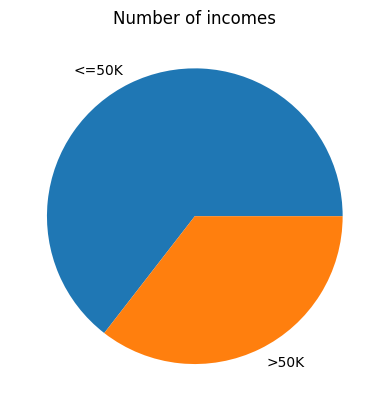

In [63]:
number_income = df['income'].value_counts().to_dict()
plt.pie(number_income.values(),labels=number_income.keys())
plt.title('Number of incomes')
plt.show()

In [64]:
mapping = {'>50K': 1,'<=50K': 0}
df['income'] = df['income'].replace(mapping)

C:\Users\Master\AppData\Local\Temp\ipykernel_29516\1516049828.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['income'] = df['income'].replace(mapping)


In [65]:

df

,age,education,marital-status,hours-per-week,workclass,income
0,56,Bachelors,Divorced,53,Private,1
1,69,HS-grad,Married,39,Private,0
2,46,Doctorate,Married,38,Self-emp,0
3,32,HS-grad,Divorced,53,Self-emp,1
4,60,Doctorate,Divorced,28,Private,0
...,...,...,...,...,...,...
49995,66,Doctorate,Single,26,Private,0
49996,35,Bachelors,Divorced,37,Private,0
49997,28,Masters,Divorced,43,Private,0
49998,59,Doctorate,Married,47,Private,1


In [66]:
le = LabelEncoder()
df['marital-status'] = le.fit_transform(df['marital-status'])
df['education'] = le.fit_transform(df['education'])
df['workclass'] = le.fit_transform(df['workclass'])

In [67]:
df

,age,education,marital-status,hours-per-week,workclass,income
0,56,0,0,53,1,1
1,69,2,1,39,1,0
2,46,1,1,38,2,0
3,32,2,0,53,2,1
4,60,1,0,28,1,0
...,...,...,...,...,...,...
49995,66,1,2,26,1,0
49996,35,0,0,37,1,0
49997,28,3,0,43,1,0
49998,59,1,1,47,1,1


In [68]:
x = df.drop(columns=['income'])
y = df['income']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [69]:
model = DecisionTreeClassifier(random_state=42,max_depth=10)
model.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

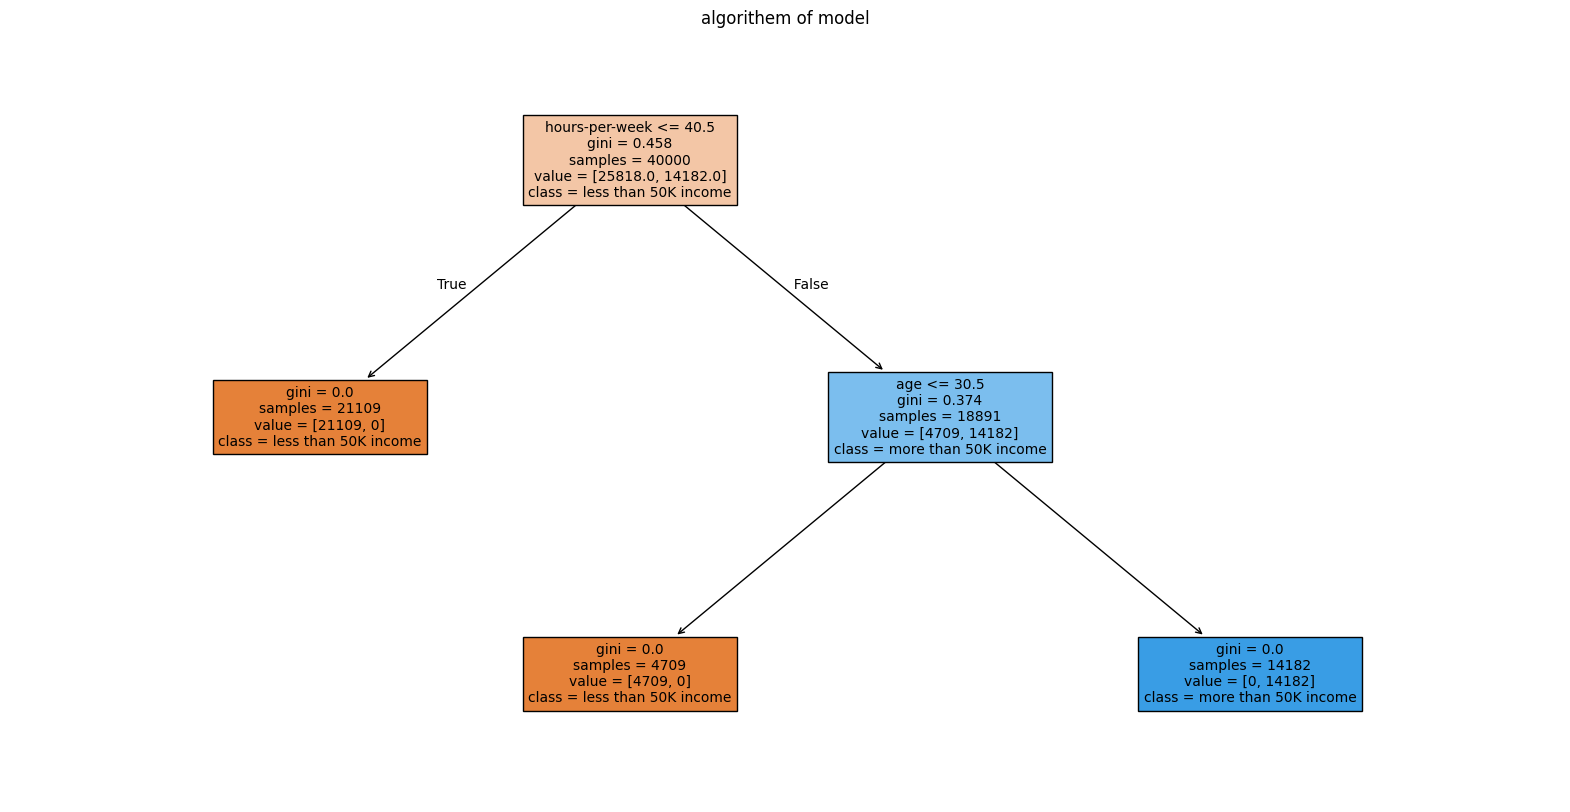

In [70]:
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=x.columns,class_names=[ 'less than 50K income','more than 50K income',], filled=True, fontsize=10,)
plt.title('algorithem of model')
plt.show()

accuracy : 1.0


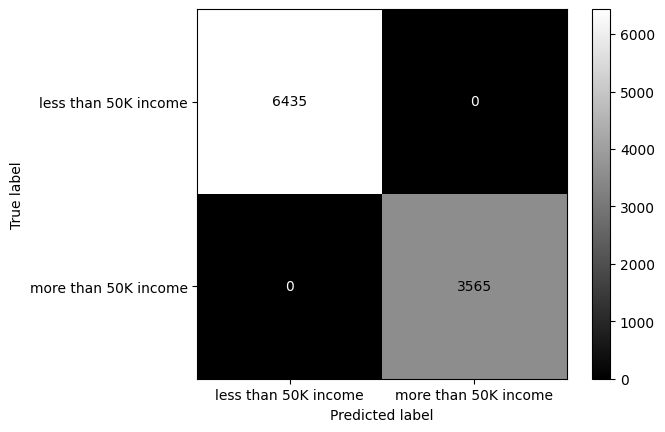

In [71]:
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_pred,y_test)
print(f'accuracy : {accuracy}')
confusion_metrix = confusion_matrix(y_test , y_pred)
displaymatrix = ConfusionMatrixDisplay(confusion_metrix ,display_labels=[ 'less than 50K income','more than 50K income',])
displaymatrix.plot(cmap = 'gray')
plt.show()